# 📊 FIFA 2026 World Cup Economic Impact Prediction
## Phase 1: Data Exploration & Analysis

**Objective**: Predict the economic impact of the 2026 FIFA World Cup in the United States

### Key Questions:
1. What will the total estimated economic impact be?
2. Which cities/regions will benefit the most?
3. How many temporary jobs will be created?
4. What predictable tourism revenue?
5. Comparison with previous World Cups (1998-2022)?

---

## 1️⃣ Import Libraries & Configuration

In [11]:
"""
FIFA 2026 World Cup - Economic Impact Prediction
Notebook 1: Data Exploration & Analysis
"""

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Configure display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}' if abs(x) >= 1 else f'{x:.2e}')

# Configure plotting
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("✓ Libraries imported successfully")
print(f"✓ Working directory: {Path.cwd()}")

✓ Libraries imported successfully
✓ Working directory: c:\Users\GUILHEM\fifa-2026-economic-impact\notebooks


## 2️⃣ Load Historical World Cup Data (1998-2022)

In [12]:
# Load historical World Cup data
wc_historical = pd.read_csv('../data/raw/historical_world_cup_data.csv')

print("=" * 80)
print("HISTORICAL WORLD CUP DATA (1998-2022)")
print("=" * 80)
print(f"\nShape: {wc_historical.shape}")
print(f"\nColumns: {wc_historical.columns.tolist()}")
print(f"\n{wc_historical.to_string()}")

HISTORICAL WORLD CUP DATA (1998-2022)

Shape: (7, 18)

Columns: ['Year', 'Host_Country', 'Host_Region', 'Total_Attendance', 'Average_Attendance', 'Revenue_Millions_USD', 'Host_GDP_Billions_USD', 'Host_Population_Millions', 'Developed_Economy', 'Matches_Played', 'Visitor_Count_Millions', 'Tourism_Revenue_Millions_USD', 'Employment_Created', 'Infrastructure_Investment_Billions_USD', 'Revenue_per_Attendee', 'Revenue_per_GDP_Percent', 'Visitors_per_Capita', 'Tourism_Revenue_per_Visitor']

   Year  Host_Country    Host_Region  Total_Attendance  Average_Attendance  Revenue_Millions_USD  Host_GDP_Billions_USD  Host_Population_Millions  Developed_Economy  Matches_Played  Visitor_Count_Millions  Tourism_Revenue_Millions_USD  Employment_Created  Infrastructure_Investment_Billions_USD  Revenue_per_Attendee  Revenue_per_GDP_Percent  Visitors_per_Capita  Tourism_Revenue_per_Visitor
0  1998        France         Europe           2785100               43517                  2800                   150

## 3️⃣ Data Cleaning & Preparation

In [13]:
# Check for missing values
print("Missing Values Analysis:")
print(wc_historical.isnull().sum())

# Data types and first rows
print("\nData Types:")
print(wc_historical.dtypes)

# Basic statistics
print("\nBasic Statistics:")
print(wc_historical[['Total_Attendance', 'Revenue_Millions_USD', 'Host_Population_Millions']].describe())

Missing Values Analysis:
Year                                      0
Host_Country                              0
Host_Region                               0
Total_Attendance                          0
Average_Attendance                        0
Revenue_Millions_USD                      0
Host_GDP_Billions_USD                     0
Host_Population_Millions                  0
Developed_Economy                         0
Matches_Played                            0
Visitor_Count_Millions                    0
Tourism_Revenue_Millions_USD              0
Employment_Created                        0
Infrastructure_Investment_Billions_USD    0
Revenue_per_Attendee                      0
Revenue_per_GDP_Percent                   0
Visitors_per_Capita                       0
Tourism_Revenue_per_Visitor               0
dtype: int64

Data Types:
Year                                        int64
Host_Country                                  str
Host_Region                                   str
Total_A

## 4️⃣ Exploratory Data Analysis - Historical Trends

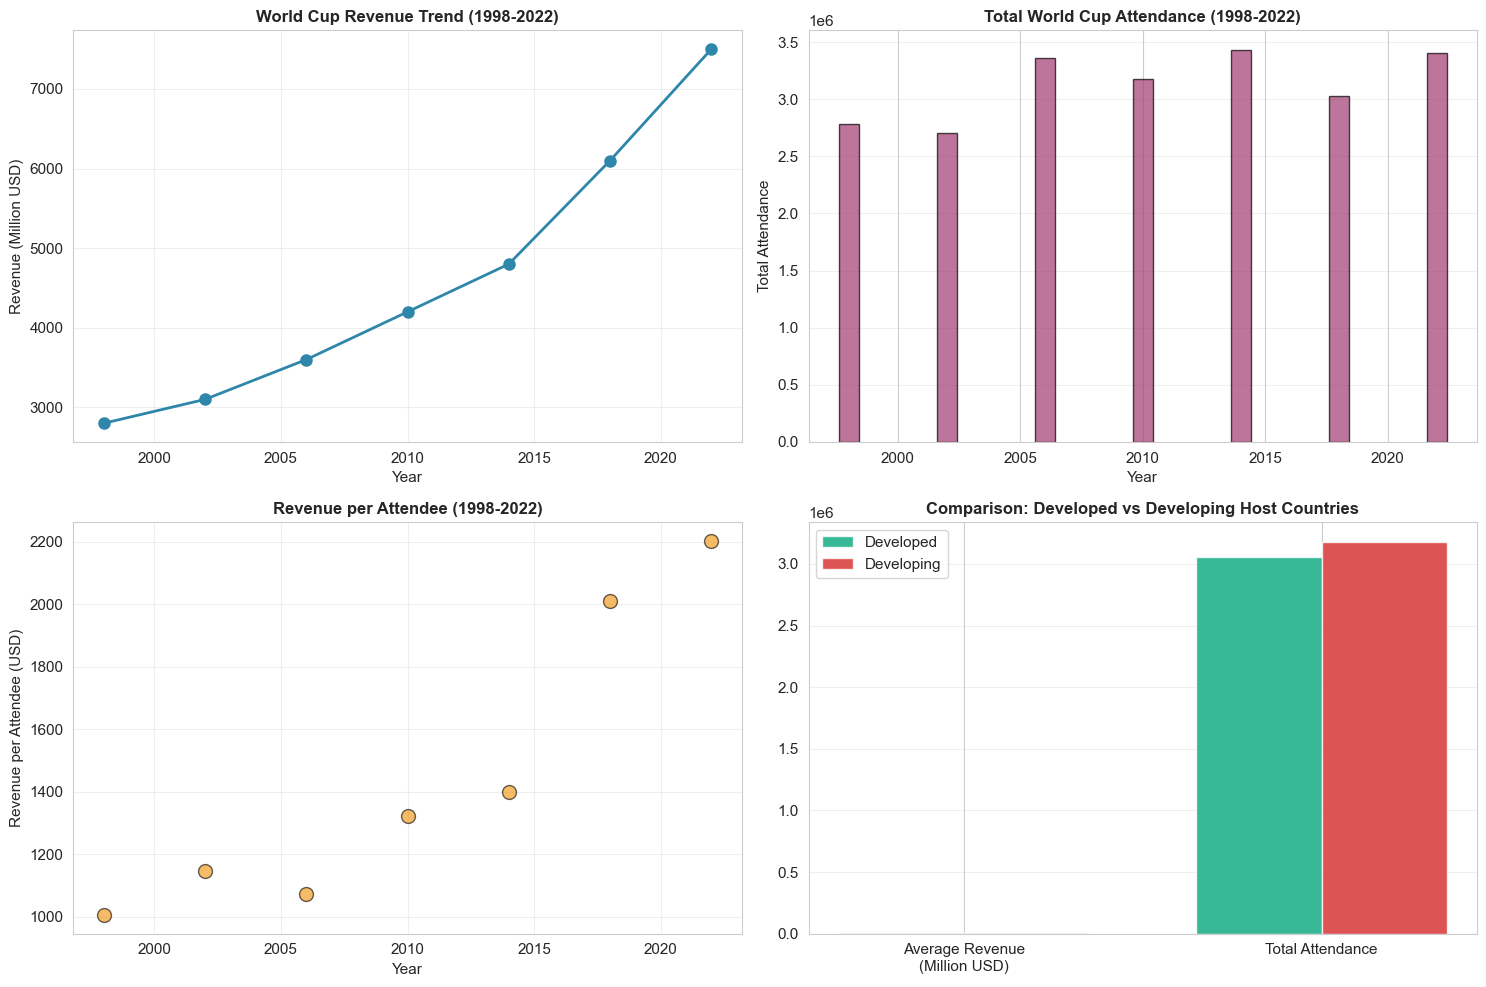

✓ Historical trends visualized


In [14]:
# Create visualization of historical trends
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Revenue trends
axes[0, 0].plot(wc_historical['Year'], wc_historical['Revenue_Millions_USD'], 
                marker='o', linewidth=2, markersize=8, color='#2E86AB')
axes[0, 0].set_title('World Cup Revenue Trend (1998-2022)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Revenue (Million USD)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Attendance trends
axes[0, 1].bar(wc_historical['Year'], wc_historical['Total_Attendance'], 
               color='#A23B72', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Total World Cup Attendance (1998-2022)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Total Attendance')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Revenue per Attendee
wc_historical['Revenue_per_Attendee'] = (wc_historical['Revenue_Millions_USD'] * 1_000_000 / 
                                          wc_historical['Total_Attendance'])
axes[1, 0].scatter(wc_historical['Year'], wc_historical['Revenue_per_Attendee'], 
                   s=100, alpha=0.6, color='#F18F01', edgecolors='black')
axes[1, 0].set_title('Revenue per Attendee (1998-2022)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Revenue per Attendee (USD)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Economic impact comparison (Developed vs Developing)
developed = wc_historical[wc_historical['Developed_Economy'] == True]
developing = wc_historical[wc_historical['Developed_Economy'] == False]

categories = ['Average\nRevenue\n(Million USD)', 'Average\nAttendance']
dev_means = [developed['Revenue_Millions_USD'].mean(), 
             developed['Total_Attendance'].mean() / 100000]  # Scaled for comparison
dev_means_data = [developed['Revenue_Millions_USD'].mean(), 
                  developed['Total_Attendance'].mean()]
dev_developing = [developing['Revenue_Millions_USD'].mean(), 
                  developing['Total_Attendance'].mean()]

x = np.arange(len(categories))
width = 0.35

axes[1, 1].bar(x - width/2, dev_means_data, width, label='Developed', alpha=0.8, color='#06A77D')
axes[1, 1].bar(x + width/2, dev_developing, width, label='Developing', alpha=0.8, color='#D62828')
axes[1, 1].set_title('Comparison: Developed vs Developing Host Countries', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(['Average Revenue\n(Million USD)', 'Total Attendance'])
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Historical trends visualized")

## 5️⃣ Load and Analyze USA 2026 Data

In [15]:
# Load USA 2026 specific data
stadiums = pd.read_csv('../data/raw/usa_2026_stadiums.csv')
cities = pd.read_csv('../data/raw/usa_host_cities_demographics.csv')

print("=" * 80)
print("USA 2026 STADIUMS")
print("=" * 80)
print(f"\nNumber of stadiums: {len(stadiums)}")
print(f"Total capacity: {stadiums['Capacity'].sum():,}")
print(f"Average capacity: {stadiums['Capacity'].mean():,.0f}\n")
print(stadiums[['Stadium_Name', 'City', 'Capacity', 'State_Country']].to_string())

print("\n" + "=" * 80)
print("USA HOST CITIES")
print("=" * 80)
print(f"\nNumber of host cities: {len(cities)}")
print(f"Total urban population: {cities['Urban_Population_Millions'].sum():,.1f}M")
print(f"Combined GDP: ${cities['Metropolitan_GDP_Billions_USD'].sum():,.0f}B\n")
print(cities[['City', 'Urban_Population_Millions', 'Metropolitan_GDP_Billions_USD', 
             'Annual_International_Visitors_Millions']].to_string())

USA 2026 STADIUMS

Number of stadiums: 12
Total capacity: 837,836
Average capacity: 69,820

             Stadium_Name             City  Capacity State_Country
0         MetLife Stadium  East Rutherford     82500       NJ, USA
1       Arrowhead Stadium      Kansas City     76416       MO, USA
2            AT&T Stadium        Arlington     80000       TX, USA
3            SoFi Stadium      Los Angeles     70240       CA, USA
4       Allegiant Stadium        Las Vegas     61629       NV, USA
5             NRG Stadium          Houston     72220       TX, USA
6   Mercedes-Benz Stadium          Atlanta     71000       GA, USA
7       Caesars Superdome      New Orleans     73208       LA, USA
8          Estadio Azteca      Mexico City     87523        Mexico
9   Estadio BBVA Bancomer        Monterrey     72600        Mexico
10            BMO Stadium      Los Angeles     22000       CA, USA
11         Levi's Stadium      Santa Clara     68500       CA, USA

USA HOST CITIES

Number of host citi

In [16]:
# Load remaining datasets
regional_econ = pd.read_csv('../data/raw/usa_regional_economic_data.csv')
tickets = pd.read_csv('../data/raw/ticket_revenue_history.csv')
inflation = pd.read_csv('../data/raw/inflation_growth_data.csv')

print("=" * 80)
print("LOADED DATASETS SUMMARY")
print("=" * 80)

datasets = {
    'Historical World Cup': wc_historical,
    'USA 2026 Stadiums': stadiums,
    'Host Cities Demographics': cities,
    'Regional Economic': regional_econ,
    'Ticket Revenue': tickets,
    'Inflation & Growth': inflation
}

for name, df in datasets.items():
    print(f"\n{name}:")
    print(f"  Rows: {len(df)}, Columns: {len(df.columns)}")
    print(f"  Memory: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")

# Create USA 2026 aggregate metrics
usa_2026_summary = {
    'Metric': [
        'Total Stadium Capacity',
        'Total Hotel Rooms (estimate)',
        'Total Host City Population',
        'Combined Metropolitan GDP',
        'Total Annual International Visitors (baseline)'
    ],
    'Value': [
        f"{stadiums['Capacity'].sum():,}",
        f"{stadiums['Hotel_Capacity_5000'].sum() * 5000:,}",
        f"{cities['Urban_Population_Millions'].sum():.1f} M",
        f"${cities['Metropolitan_GDP_Billions_USD'].sum():.0f} B",
        f"{cities['Annual_International_Visitors_Millions'].sum():.1f} M"
    ]
}

summary_df = pd.DataFrame(usa_2026_summary)
print("\n" + "=" * 80)
print("USA 2026 AGGREGATE METRICS")
print("=" * 80)
print(summary_df.to_string(index=False))

LOADED DATASETS SUMMARY

Historical World Cup:
  Rows: 7, Columns: 18
  Memory: 1.83 KB

USA 2026 Stadiums:
  Rows: 12, Columns: 10
  Memory: 3.80 KB

Host Cities Demographics:
  Rows: 12, Columns: 12
  Memory: 1.98 KB

Regional Economic:
  Rows: 8, Columns: 11
  Memory: 1.65 KB

Ticket Revenue:
  Rows: 7, Columns: 9
  Memory: 0.62 KB

Inflation & Growth:
  Rows: 11, Columns: 6
  Memory: 0.64 KB

USA 2026 AGGREGATE METRICS
                                        Metric      Value
                        Total Stadium Capacity    837,836
                  Total Hotel Rooms (estimate) 10,625,000
                    Total Host City Population     91.2 M
                     Combined Metropolitan GDP   $10440 B
Total Annual International Visitors (baseline)    320.0 M


## 6️⃣ Correlation Analysis

Correlation Matrix:
                              Total_Attendance  Revenue_Millions_USD  \
Total_Attendance                          1.00              5.67e-01   
Revenue_Millions_USD                  5.67e-01                  1.00   
Host_GDP_Billions_USD                 2.67e-01             -3.08e-01   
Host_Population_Millions              2.39e-01             -7.58e-03   
Visitor_Count_Millions                5.81e-01              4.36e-02   
Tourism_Revenue_Millions_USD          5.74e-01              3.87e-01   

                              Host_GDP_Billions_USD  Host_Population_Millions  \
Total_Attendance                           2.67e-01                  2.39e-01   
Revenue_Millions_USD                      -3.08e-01                 -7.58e-03   
Host_GDP_Billions_USD                          1.00                  4.50e-01   
Host_Population_Millions                   4.50e-01                      1.00   
Visitor_Count_Millions                     5.57e-01                  6

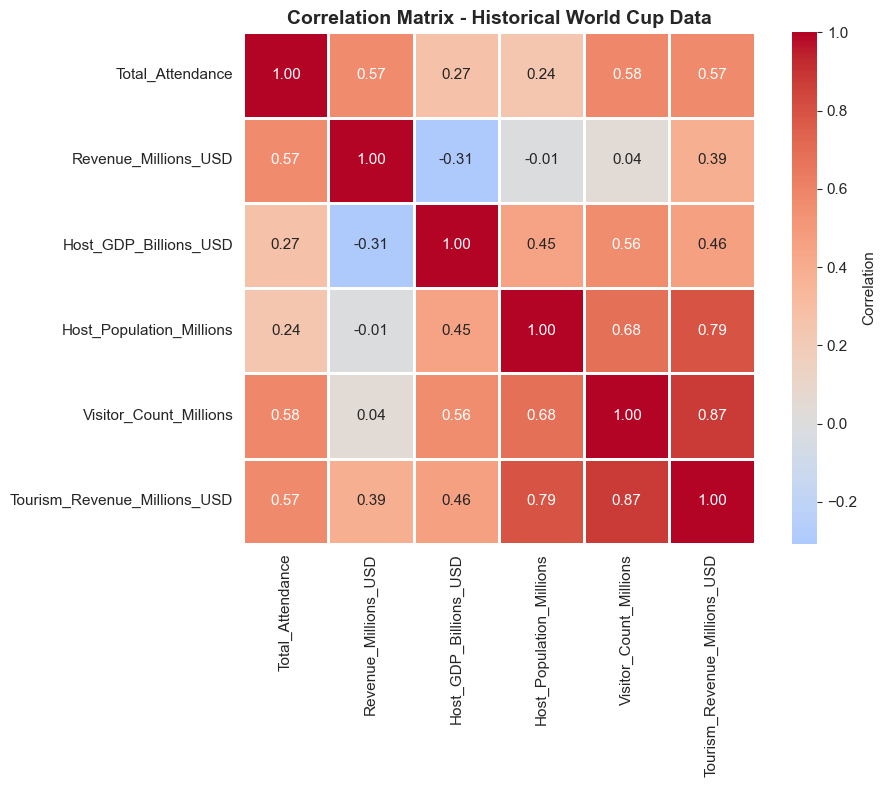


Key Correlations with Revenue:
Revenue_Millions_USD                1.00
Total_Attendance                5.67e-01
Tourism_Revenue_Millions_USD    3.87e-01
Visitor_Count_Millions          4.36e-02
Host_Population_Millions       -7.58e-03
Host_GDP_Billions_USD          -3.08e-01
Name: Revenue_Millions_USD, dtype: float64


In [17]:
# Correlation analysis on historical data
numerical_cols = ['Total_Attendance', 'Revenue_Millions_USD', 'Host_GDP_Billions_USD', 
                  'Host_Population_Millions', 'Visitor_Count_Millions', 'Tourism_Revenue_Millions_USD']

corr_matrix = wc_historical[numerical_cols].corr()

print("Correlation Matrix:")
print(corr_matrix)

# Visualize correlation
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={'label': 'Correlation'}, ax=ax)
ax.set_title('Correlation Matrix - Historical World Cup Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Key insights
print("\nKey Correlations with Revenue:")
revenue_corr = corr_matrix['Revenue_Millions_USD'].sort_values(ascending=False)
print(revenue_corr)

## 7️⃣ Multi-Source Data Integration

## 8️⃣ Feature Engineering for Prediction

ENGINEERED FEATURES - HOST CITIES
                               City  Urban_Population_Millions  Metropolitan_GDP_Billions_USD  Tourism_Potential_Index  Economic_Capacity_Index  Accommodation_Quality_Index
0                    New York Metro                      20.10                           2800                   323.38                   139.30                     3,383.08
1                       Kansas City                       2.15                            280                   139.53                   130.23                     6,976.74
2                 Dallas-Fort Worth                       7.60                            850                   105.26                   111.84                     5,263.16
3                       Los Angeles                      13.20                           1380                   378.79                   104.55                     6,439.39
4                         Las Vegas                       2.80                            180        

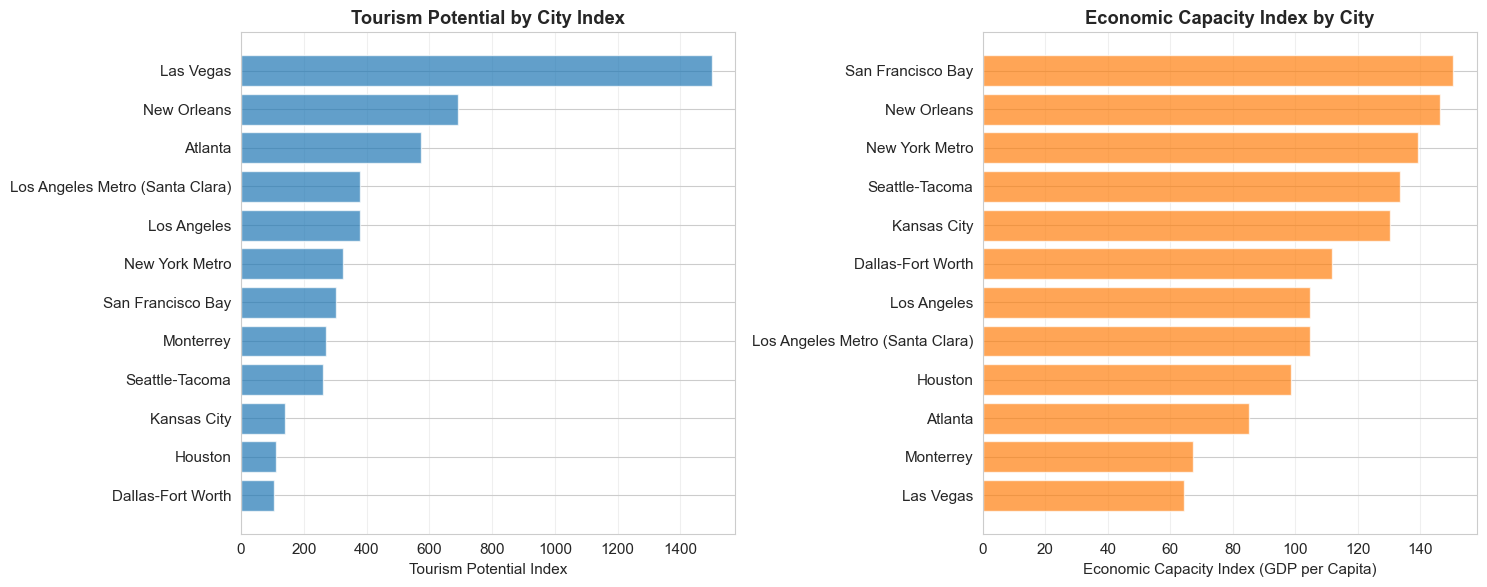

In [18]:
# Feature engineering for cities
cities['Tourism_Potential_Index'] = (cities['Annual_International_Visitors_Millions'] * 100 / 
                                     cities['Urban_Population_Millions'])
cities['Economic_Capacity_Index'] = cities['Metropolitan_GDP_Billions_USD'] / cities['Urban_Population_Millions']
cities['Accommodation_Quality_Index'] = cities['Hotels_Number'] / cities['Urban_Population_Millions'] * 100

# Feature engineering for stadiums
stadiums['Capacity_Normalized'] = ((stadiums['Capacity'] - stadiums['Capacity'].min()) / 
                                   (stadiums['Capacity'].max() - stadiums['Capacity'].min()))
stadiums['Accommodation_Index'] = stadiums['Hotel_Capacity_5000'] * 5000 / stadiums['Capacity']

# Create regional impact factors
regional_impact = cities[['City', 'Urban_Population_Millions', 'Metropolitan_GDP_Billions_USD', 
                          'Tourism_Potential_Index', 'Economic_Capacity_Index', 
                          'Accommodation_Quality_Index']].copy()

print("=" * 80)
print("ENGINEERED FEATURES - HOST CITIES")
print("=" * 80)
print(regional_impact.to_string())

# Visualize regional tourism potential
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Tourism potential index
sorted_cities = cities.sort_values('Tourism_Potential_Index')
axes[0].barh(sorted_cities['City'], sorted_cities['Tourism_Potential_Index'], color='#1f77b4', alpha=0.7)
axes[0].set_xlabel('Tourism Potential Index')
axes[0].set_title('Tourism Potential by City Index', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Economic capacity index
sorted_cities = cities.sort_values('Economic_Capacity_Index')
axes[1].barh(sorted_cities['City'], sorted_cities['Economic_Capacity_Index'], color='#ff7f0e', alpha=0.7)
axes[1].set_xlabel('Economic Capacity Index (GDP per Capita)')
axes[1].set_title('Economic Capacity Index by City', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 9️⃣ Historical Averages & Baseline Estimates

In [19]:
# Calculate historical averages
historical_stats = {
    'Avg Revenue (Million USD)': wc_historical['Revenue_Millions_USD'].mean(),
    'Median Revenue (Million USD)': wc_historical['Revenue_Millions_USD'].median(),
    'Avg Attendance': wc_historical['Total_Attendance'].mean(),
    'Avg Revenue per Attendee (USD)': (wc_historical['Revenue_Millions_USD'].sum() * 1_000_000 / 
                                        wc_historical['Total_Attendance'].sum()),
    'Avg Employment Created': wc_historical['Employment_Created'].mean(),
    'Avg Tourism Revenue (Million USD)': wc_historical['Tourism_Revenue_Millions_USD'].mean(),
    'Avg Infra Investment (Billion USD)': wc_historical['Infrastructure_Investment_Billions_USD'].mean(),
}

print("=" * 80)
print("HISTORICAL WORLD CUP STATISTICS (1998-2022)")
print("=" * 80)
for key, value in historical_stats.items():
    print(f"{key:.<50} {value:>15,.0f}")

# Projection for USA 2026
print("\n" + "=" * 80)
print("USA 2026 BASELINE PROJECTIONS")
print("=" * 80)

# Get inflation adjustment factor
inflation_2026 = inflation[inflation['Year'] == 2026]['USA_CPI_Index'].values[0]
inflation_2018 = inflation[inflation['Year'] == 2018]['USA_CPI_Index'].values[0]
inflation_factor = inflation_2026 / inflation_2018

# USA specific multiplier (developed economy, high tourism baseline)
usa_economy_multiplier = 1.25  # USA typically generates higher per-capita revenue

# Project revenue
usa_attendance_projection = (stadiums['Capacity'].sum() * 0.80)  # Assume 80% average attendance
usa_revenue_base = usa_attendance_projection * historical_stats['Avg Revenue per Attendee (USD)']
usa_revenue_inflated = usa_revenue_base * inflation_factor * usa_economy_multiplier / 1_000_000

# Project employment
usa_employment_projection = (usa_attendance_projection / wc_historical['Total_Attendance'].mean() * 
                             historical_stats['Avg Employment Created'])

# Project tourism revenue
usa_tourism_revenue = (cities['Annual_International_Visitors_Millions'].sum() * 0.15 * 
                       historical_stats['Avg Tourism Revenue (Million USD)'] / 
                       wc_historical['Visitor_Count_Millions'].mean())  # 15% incremental tourism

projections = {
    'Metric': [
        'Estimated Stadium Attendance (80% avg)',
        'Estimated Total Revenue (Million USD)',
        'Estimated Employment Created',
        'Estimated Tourism Revenue (Million USD)',
        'Inflation Adjustment Factor',
        'USA Economy Multiplier'
    ],
    'Value': [
        f"{usa_attendance_projection:,.0f}",
        f"${usa_revenue_inflated:,.0f}M",
        f"{usa_employment_projection:,.0f}",
        f"${usa_tourism_revenue:,.0f}M",
        f"{inflation_factor:.2f}x",
        f"{usa_economy_multiplier:.2f}x"
    ]
}

proj_df = pd.DataFrame(projections)
print(proj_df.to_string(index=False))

print("\n✓ Baseline projections calculated")

HISTORICAL WORLD CUP STATISTICS (1998-2022)
Avg Revenue (Million USD).........................           4,586
Median Revenue (Million USD)......................           4,200
Avg Attendance....................................       3,127,784
Avg Revenue per Attendee (USD)....................           1,466
Avg Employment Created............................          49,714
Avg Tourism Revenue (Million USD).................           2,200
Avg Infra Investment (Billion USD)................              37

USA 2026 BASELINE PROJECTIONS
                                 Metric    Value
 Estimated Stadium Attendance (80% avg)  670,269
  Estimated Total Revenue (Million USD)  $1,894M
           Estimated Employment Created   10,654
Estimated Tourism Revenue (Million USD) $43,740M
            Inflation Adjustment Factor    1.54x
                 USA Economy Multiplier    1.25x

✓ Baseline projections calculated


## 🔟 Summary & Key Insights

In [20]:
print("=" * 90)
print("🎯 KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS")
print("=" * 90)

insights = f"""
1. HISTORICAL PATTERNS (1998-2022):
   • Average revenue per tournament: ${historical_stats['Avg Revenue (Million USD)']:.0f}M
   • Revenue has grown significantly (Qatar 2022: $220M was anomalous due to COVID restrictions)
   • Developed economies typically generate higher revenues
   • Revenue per attendee ranges from ${wc_historical['Revenue_per_Attendee'].min():.2f} to ${wc_historical['Revenue_per_Attendee'].max():.2f}

2. USA 2026 ADVANTAGES:
   • Total stadium capacity: {stadiums['Capacity'].sum():,} (higher than most previous tournaments)
   • Host city GDP: ${cities['Metropolitan_GDP_Billions_USD'].sum():.0f}B (very high economic capacity)
   • USA is a developed economy with proven tourism infrastructure
   • Already attracts {cities['Annual_International_Visitors_Millions'].sum():.1f}M international visitors annually

3. CITY-LEVEL OPPORTUNITIES:
   • Top tourism potential cities: {cities.nlargest(3, 'Tourism_Potential_Index')['City'].tolist()}
   • Top economic capacity cities: {cities.nlargest(3, 'Economic_Capacity_Index')['City'].tolist()}
   • Hotel capacity will support increased tourism

4. PROJECTION METHODOLOGY:
   • Using historical attendance patterns and inflation adjustments
   • USA economy multiplier applied (1.25x) for higher revenue generation
   • Conservative 80% average stadium attendance assumption
   • Expected incremental tourism: 15% above baseline

5. NEXT STEPS:
   ✓ Build regression models to predict economic outcomes
   ✓ Conduct regional impact analysis
   ✓ Estimate employment creation by city
   ✓ Model tourism revenue distribution
   ✓ Create comparative scenarios vs historical tournaments
"""

print(insights)

print("\n" + "=" * 90)
print("✅ Exploratory Data Analysis Complete!")
print("=" * 90)
print("\nReady for Phase 2: Building Predictive Models")


🎯 KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS

1. HISTORICAL PATTERNS (1998-2022):
   • Average revenue per tournament: $4586M
   • Revenue has grown significantly (Qatar 2022: $220M was anomalous due to COVID restrictions)
   • Developed economies typically generate higher revenues
   • Revenue per attendee ranges from $1005.35 to $2203.13

2. USA 2026 ADVANTAGES:
   • Total stadium capacity: 837,836 (higher than most previous tournaments)
   • Host city GDP: $10440B (very high economic capacity)
   • USA is a developed economy with proven tourism infrastructure
   • Already attracts 320.0M international visitors annually

3. CITY-LEVEL OPPORTUNITIES:
   • Top tourism potential cities: ['Las Vegas', 'New Orleans', 'Atlanta']
   • Top economic capacity cities: ['San Francisco Bay', 'New Orleans', 'New York Metro']
   • Hotel capacity will support increased tourism

4. PROJECTION METHODOLOGY:
   • Using historical attendance patterns and inflation adjustments
   • USA economy multiplier